# ARTIFICIAL NEURAL NETWORKS

Classification Using Artificial Neural Networks with Hyperparameter Tuning on Alphabets Data

Overview

In this assignment, you will be tasked with developing a classification model using Artificial Neural Networks (ANNs) to classify data points from the "Alphabets_data.csv" dataset into predefined categories of alphabets. This exercise aims to deepen your understanding of ANNs and the significant role hyperparameter tuning plays in enhancing model performance.

Dataset: "Alphabets_data.csv"

The dataset provided, "Alphabets_data.csv", consists of labeled data suitable for a classification task aimed at identifying 
different alphabets. Before using this data in your model, you'll need to preprocess it to ensure optimal performance.

Tasks

1. Data Exploration and Preprocessing

●	Begin by loading and exploring the "Alphabets_data.csv" dataset. Summarize its key features such as the number of samples, features, and classes.

●	Execute necessary data preprocessing steps including data normalization, managing missing values.

2. Model Implementation

●	Construct a basic ANN model using your chosen high-level neural network library. Ensure your model includes at least one hidden layer.

●	Divide the dataset into training and test sets.

●	Train your model on the training set and then use it to make predictions on the test set.

3. Hyperparameter Tuning

●	Modify various hyperparameters, such as the number of hidden layers, neurons per hidden layer, activation functions, and learning rate, to observe their impact on model performance.

●	Adopt a structured approach like grid search or random search for hyperparameter tuning, documenting your methodology thoroughly.

4. Evaluation

●	Employ suitable metrics such as accuracy, precision, recall, and F1-score to evaluate your model's performance.

●	Discuss the performance differences between the model with default hyperparameters and the tuned model, emphasizing the effects of hyperparameter tuning.


## Answer

In [1]:
!pip install keras

In [25]:
!pip install tensorflow

In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reading the dataset
df = pd.read_csv(r"C:\Users\musku\Downloads\Neural networks\Neural networks\Alphabets_data.csv")
df


,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19996,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19997,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19998,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8


In [4]:
# Check for null values
df.isnull().sum()

letter    0
xbox      0
ybox      0
width     0
height    0
onpix     0
xbar      0
ybar      0
x2bar     0
y2bar     0
xybar     0
x2ybar    0
xy2bar    0
xedge     0
xedgey    0
yedge     0
yedgex    0
dtype: int64

In [5]:
# Check for duplicates
df.duplicated().sum()

1332

In [6]:



# Remove duplicates to remove bias
df.drop_duplicates(inplace=True)

In [7]:
df.describe()

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
count,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000
mean,4.150793,7.244322,5.279891,5.506910,3.660596,6.919381,7.529409,4.584637,5.201361,8.353171,6.452700,7.924577,3.131455,8.351832,3.796872,7.784390
std,1.879428,3.187660,1.934960,2.178292,2.160555,2.032226,2.319834,2.625714,2.320102,2.468905,2.624673,2.106957,2.323901,1.574853,2.540271,1.657358
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,4.000000,4.000000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.000000,7.000000,2.000000,8.000000,2.000000,7.000000
50%,4.000000,8.000000,5.000000,6.000000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.000000,8.000000,3.000000,8.000000,4.000000,8.000000
75%,5.000000,10.000000,6.000000,7.000000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.000000,9.000000,4.000000,9.000000,5.000000,9.000000
max,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000


<Axes: xlabel='count', ylabel='letter'>

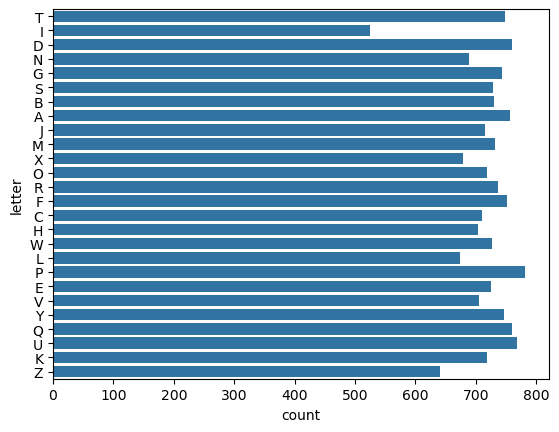

In [8]:
# Checking distribution of target classes
sns.countplot(df["letter"])

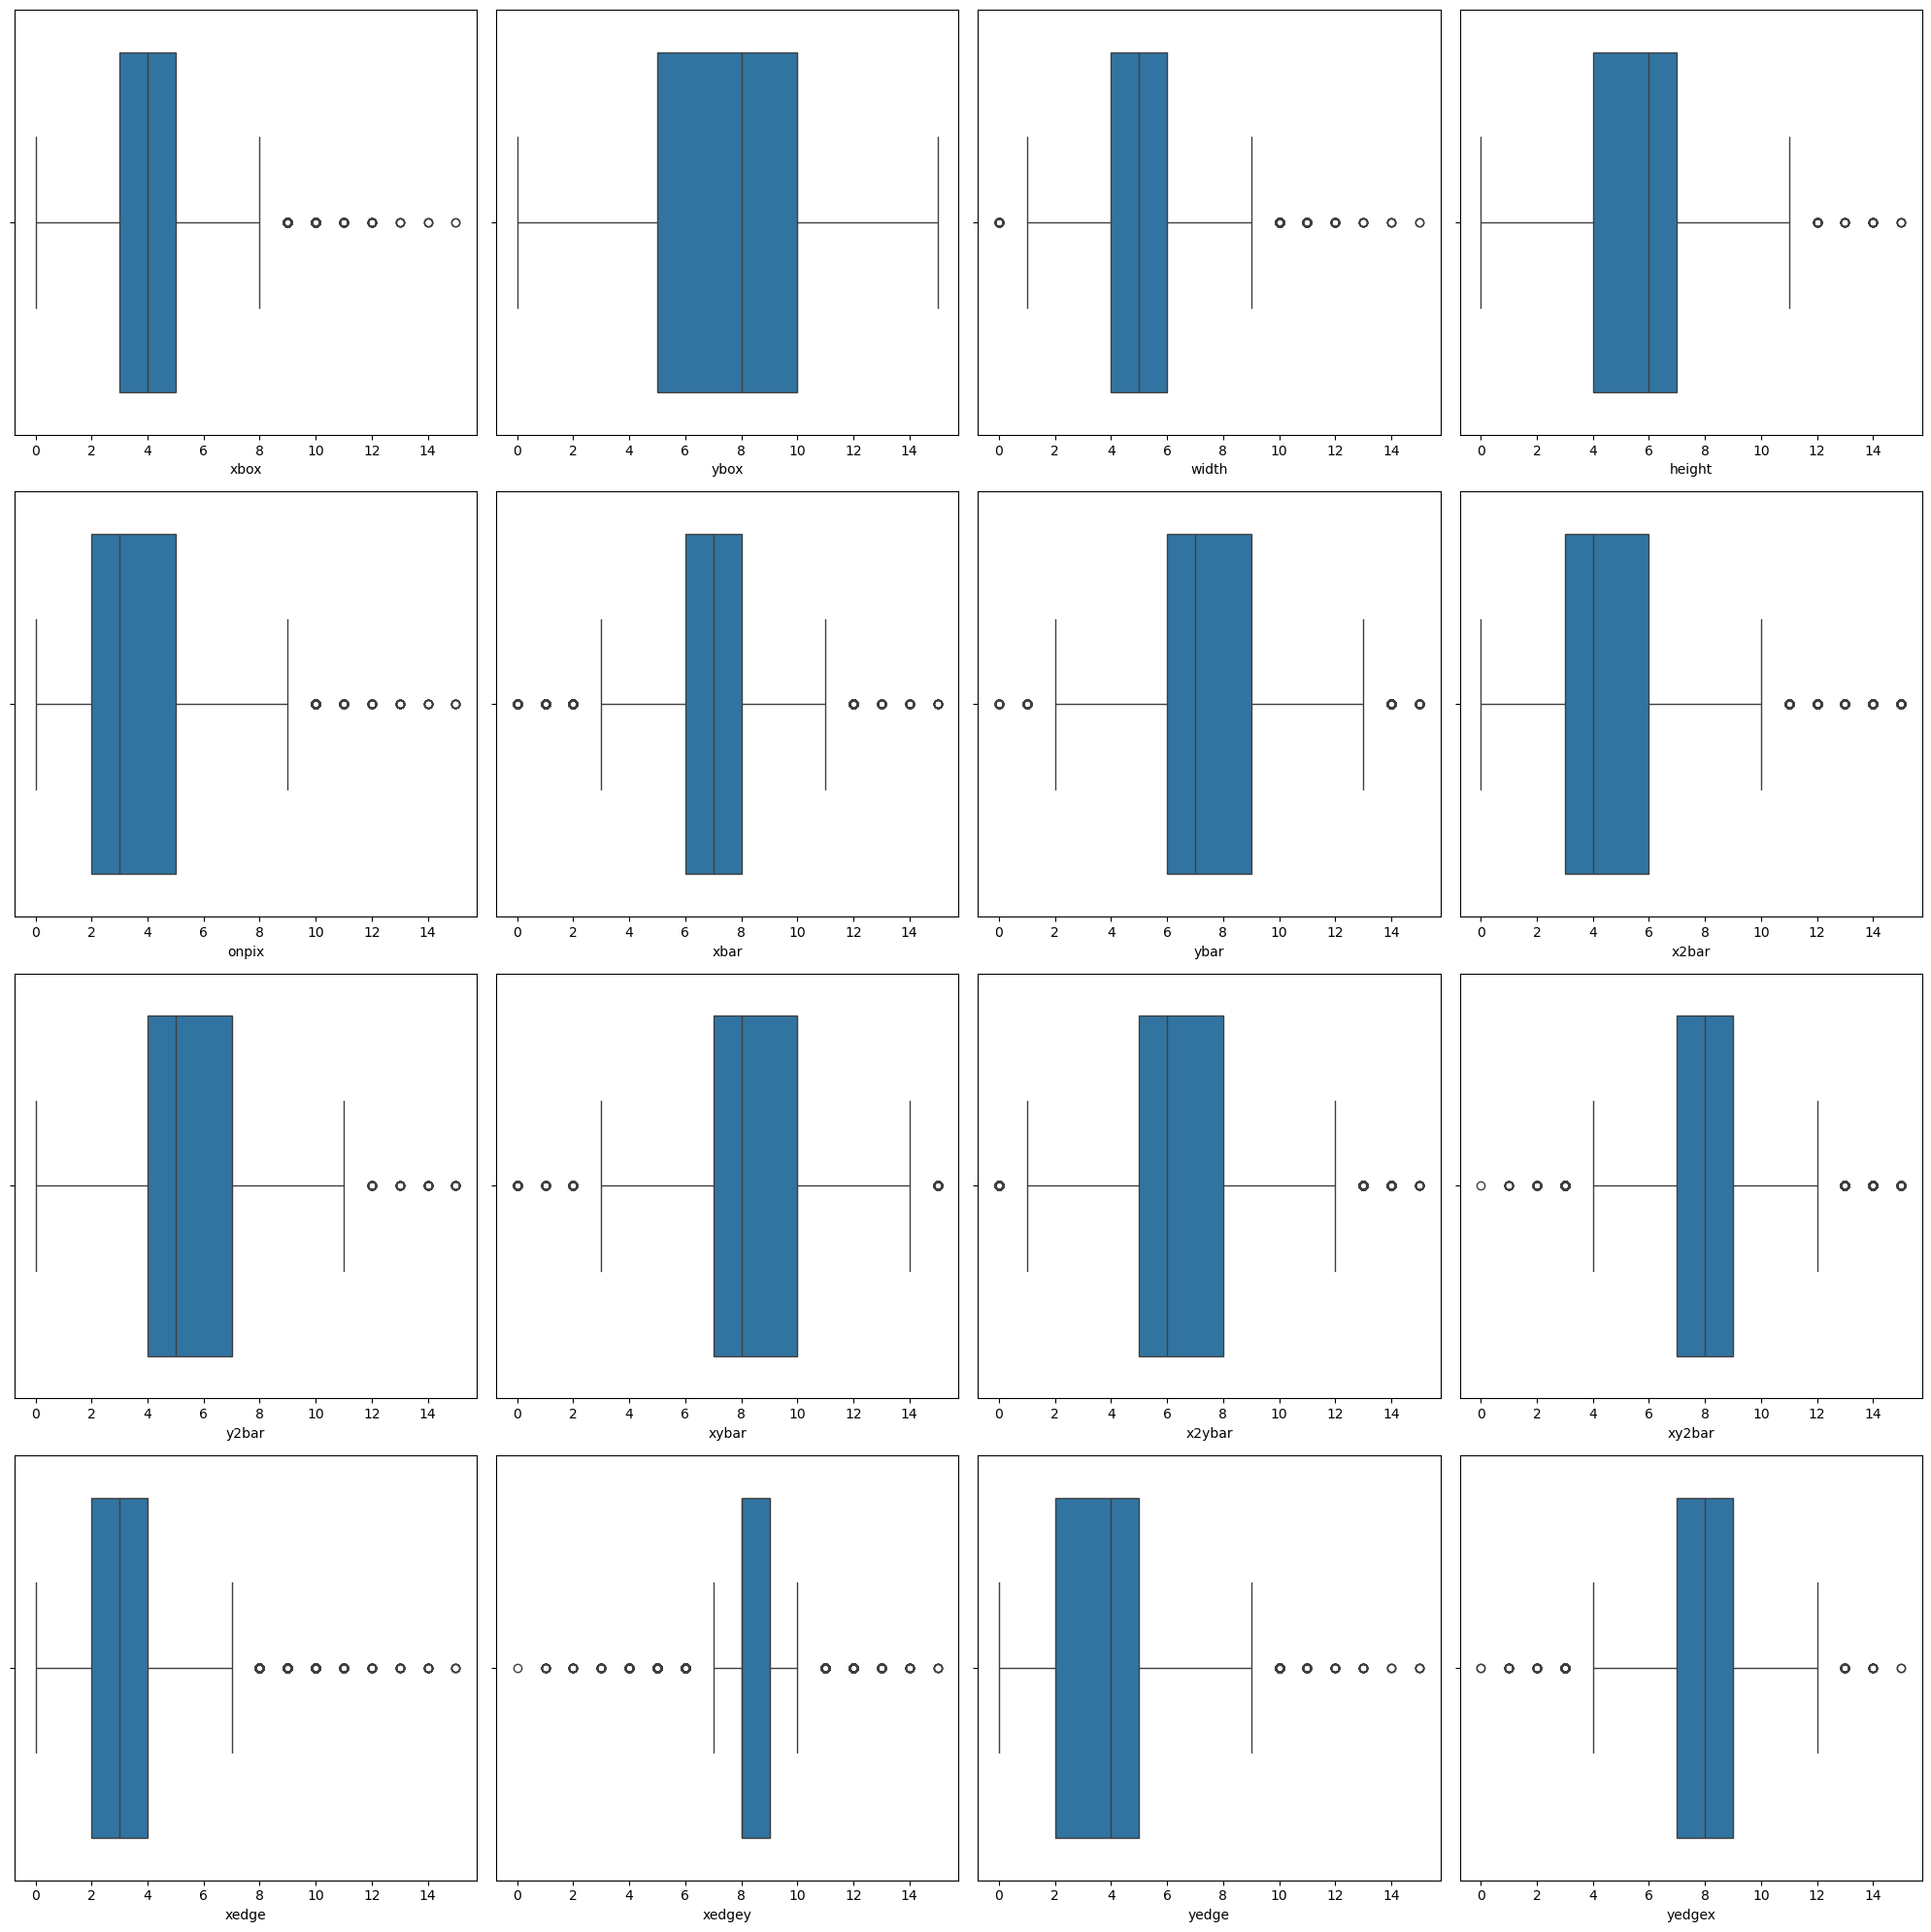

In [9]:
# Plotting boxplots to check the distribution of numerical columns
cols = df.columns[1:].tolist()  # Exclude the last column
fig, ax = plt.subplots(4, 4, figsize=(20, 20))  # 4 rows, 4 columns for the subplots
r = c = 0
for col in cols:
    sns.boxplot(x=col, data=df, ax=ax[r, c])
    c += 1
    if c == 4:
        r += 1
        c = 0
plt.tight_layout()
plt.show()

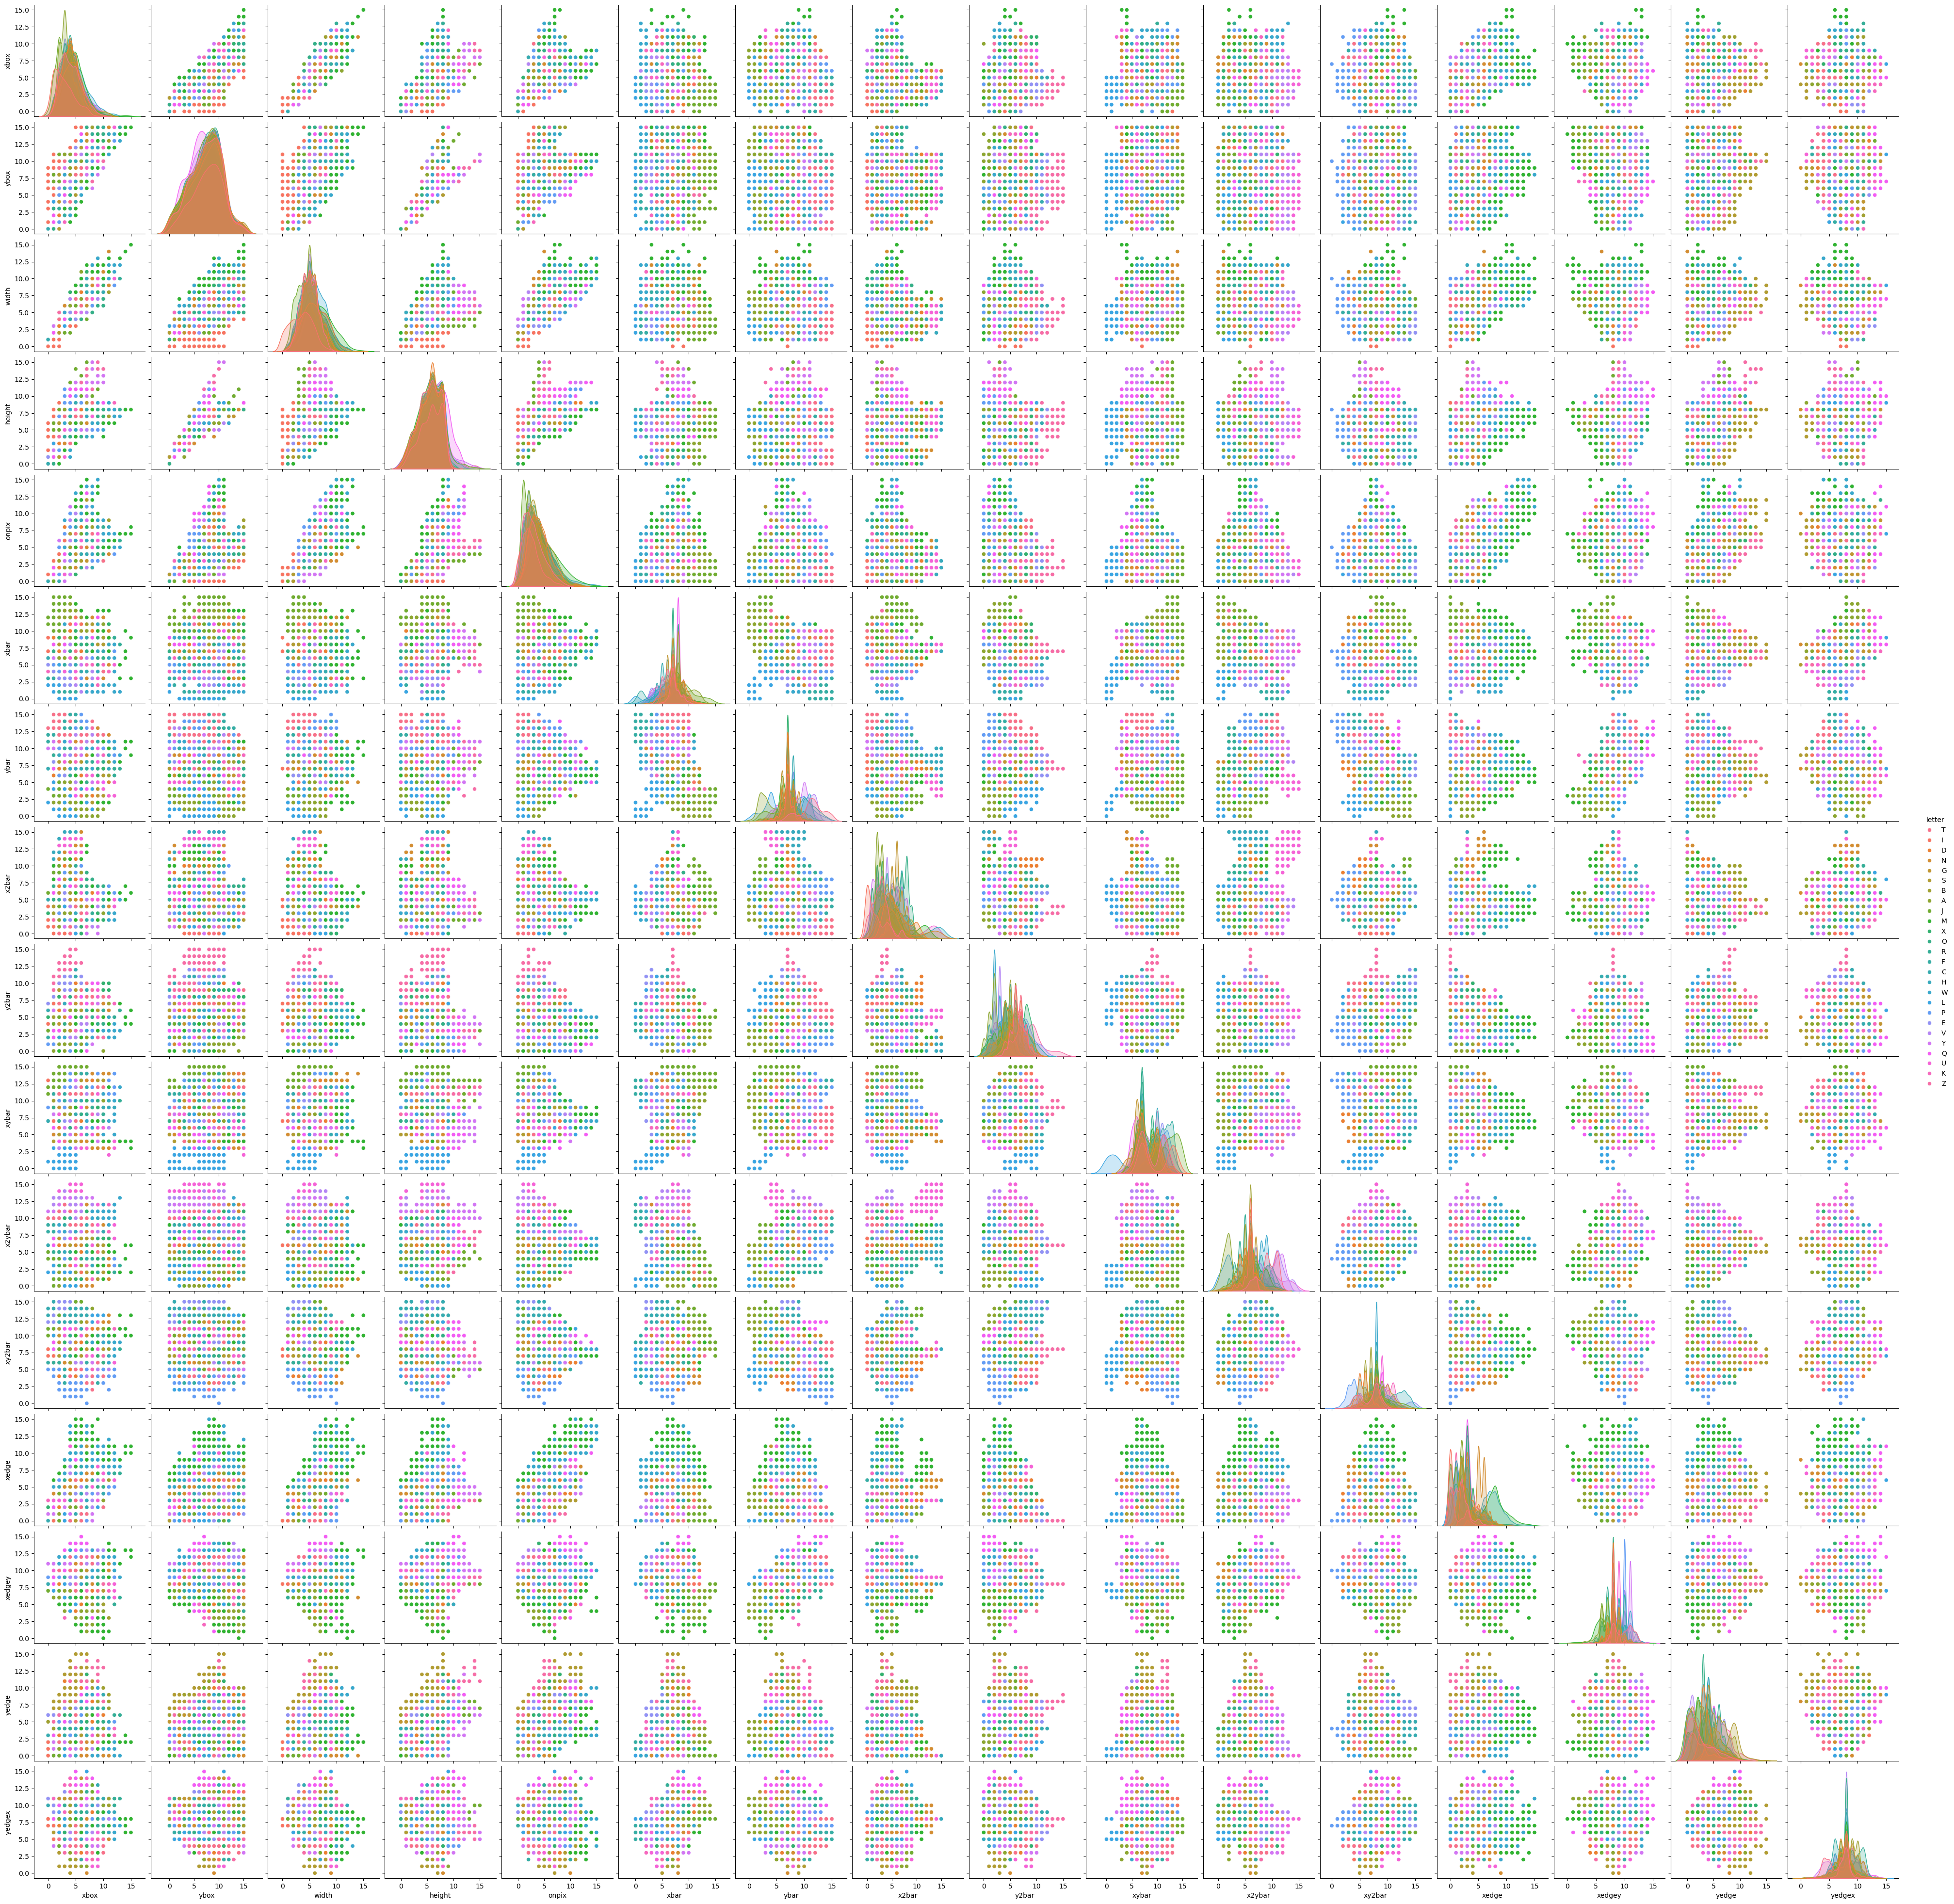

In [14]:
# Visualizing numerical columns clustered based on species
sns.pairplot(df,hue='letter')

In [10]:
# Train-test split

X = df.drop('letter',axis=1).values
# Since this ia a multiclass-classification, output labels are one-hot encoded for training the ANN
y = pd.get_dummies(df['letter']).values

In [32]:
print(X.shape)

(18668, 16)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  = train_test_split(X,y,test_size=0.25,random_state=101)

In [12]:
# Performing min-max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
!pip install tensorflow

In [17]:
!pip install tensorflow scikeras


In [20]:
# Importing keras related libraries
#import tensorflow
#import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier


In [21]:
# input_shape
X_train_scaled.shape[1:]

(16,)

In [22]:
def build_model(n_hidden = 1, n_neurons=5, learning_rate=3e-3, input_shape=X_train_scaled.shape[1:]):
  '''
  Builds a keras ANN for Multi-Class Classification i.e. output classes which are mutually exclusive
  ''' 
  model = Sequential()
  options = {"input_shape": input_shape}
  # Adding input and hidden layers
  for layer in range(n_hidden):
    model.add(Dense(n_neurons,activation="relu",**options))
    options = {}
  # Adding output layer having 3 neurons, 1 per class
  model.add(Dense(3,activation='softmax'))
  # Creating instance of adam optimizer
  opt = Adam(learning_rate=learning_rate)
  model.compile(optimizer=opt,loss='categorical_crossentropy',metrics='accuracy')
  return model

In [23]:
# Applying KerasClassifier Wrapper to neural network
keras_cls = KerasClassifier(build_model)

In [30]:
# Hyperparameter tuning

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import RandomizedSearchCV

param_dict = {
    "n_hidden" : (2,3),
    "n_neurons" : tuple(range(2,7)),
    "learning_rate" : (3e-2,3e-3,3e-4)
}

model_cv = RandomizedSearchCV(keras_cls, param_dict, n_iter=10, cv=3)

In [33]:
%%time
model_cv.fit(
    X_train_scaled, y_train, epochs=150,
    validation_data = (X_test_scaled,y_test),
    callbacks = [EarlyStopping(monitor='val_loss', mode='min', verbose=0, patience=10)],
    verbose=0
)

ValueError: Invalid parameter n_neurons for estimator KerasClassifier.
This issue can likely be resolved by setting this parameter in the KerasClassifier constructor:
`KerasClassifier(n_neurons=6)`
Check the list of available parameters with `estimator.get_params().keys()`

In [28]:
model_cv.best_params_

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_params_'

In [35]:
model_cv.best_score_

NameError: name 'model_cv' is not defined

In [ ]:
# building model based on best set of parameters obtained from RandomSearchCV

best_set = model_cv.best_params_

model = build_model(learning_rate= best_set['learning_rate'], 
                    n_hidden= best_set['n_hidden'], n_neurons= best_set['n_neurons'])

In [ ]:
model.fit(
    X_train_scaled, y_train, epochs=100,
    validation_data = (X_test_scaled,y_test),
    callbacks = [EarlyStopping(monitor='val_loss', mode='min', patience=10)],
    verbose=0
)

In [ ]:
# Plotting accuracy, loss of train and validation set
pd.DataFrame(model.history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [ ]:
# Model Evaluation

from sklearn.metrics import classification_report,confusion_matrix

# Instead of probabilities it provides class labels
pred_classes = model.predict_classes(X_test_scaled)
y_test_classes = np.argmax(y_test,axis=1)
print(classification_report(y_test_classes,pred_classes),"\n\n")
print(confusion_matrix(y_test_classes,pred_classes))